# Notebook 03 — Model Comparison

Compares LightGBM, XGBoost, CatBoost, SVM baseline, GBDT ensemble, and calibrated ensemble
using out-of-fold (OOF) predictions from the 5-fold cross-validation run in `train.py`.

**Loads:** `outputs/oof_predictions.csv` and `outputs/cv_results.json`

**Metric:** pAUC above 80% TPR (range [0.0, 0.2]) — exact Kaggle competition implementation.

## 1. Setup

In [8]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"] = 11

OUTPUTS = Path("../outputs")
assert OUTPUTS.exists(), f"Run train.py first — {OUTPUTS} not found"

oof_df = pd.read_csv(OUTPUTS / "oof_predictions.csv")
with open(OUTPUTS / "cv_results.json") as f:
    cv = json.load(f)

print(f"OOF shape: {oof_df.shape}")
print(f"Models: {[c for c in oof_df.columns if c not in ('isic_id', 'target')]}")
print(f"Positives: {oof_df['target'].sum():.0f} / {len(oof_df):,}")

OOF shape: (401059, 8)
Models: ['lgbm', 'xgb', 'catboost', 'svm', 'ensemble', 'ensemble_calibrated']
Positives: 393 / 401,059


## 2. pAUC Bar Chart (mean ± std across folds)

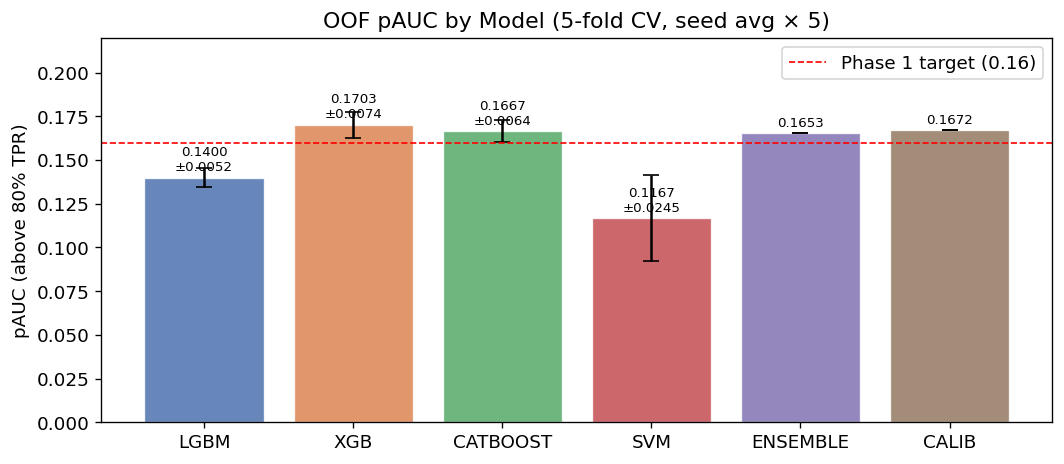

In [9]:
model_names = ["lgbm", "xgb", "catboost", "svm"]
means = [cv[m]["mean_pauc"] for m in model_names]
stds  = [cv[m]["std_pauc"]  for m in model_names]

# Add ensemble + calibrated ensemble (OOF-level, no per-fold std)
ensemble_pauc = cv["ensemble"]["oof_metrics"]["pauc"]
calib_pauc    = cv["ensemble_calibrated"]["oof_metrics"]["pauc"]

all_names  = model_names + ["ensemble", "calib"]
all_means  = means + [ensemble_pauc, calib_pauc]
all_stds   = stds  + [0.0, 0.0]  # no fold-level std for OOF ensemble

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(all_names))
bars = ax.bar(x, all_means, yerr=all_stds, capsize=5,
              color=colors, alpha=0.85, edgecolor="white", linewidth=0.8)

ax.axhline(0.16, color="red", linestyle="--", linewidth=1, label="Phase 1 target (0.16)")
ax.set_xticks(x)
ax.set_xticklabels([n.upper() for n in all_names])
ax.set_ylabel("pAUC (above 80% TPR)")
ax.set_title("OOF pAUC by Model (5-fold CV, seed avg × 5)")
ax.legend()
ax.set_ylim(0, 0.22)

for bar, mean, std in zip(bars, all_means, all_stds):
    label = f"{mean:.4f}" if std == 0 else f"{mean:.4f}\n±{std:.4f}"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            label, ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Per-Fold pAUC Box Plot

/var/folders/h1/2p953_l170l_j2lsyv8mgd6c0000gn/T/ipykernel_5821/545646281.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(fold_data, labels=[n.upper() for n in model_names],


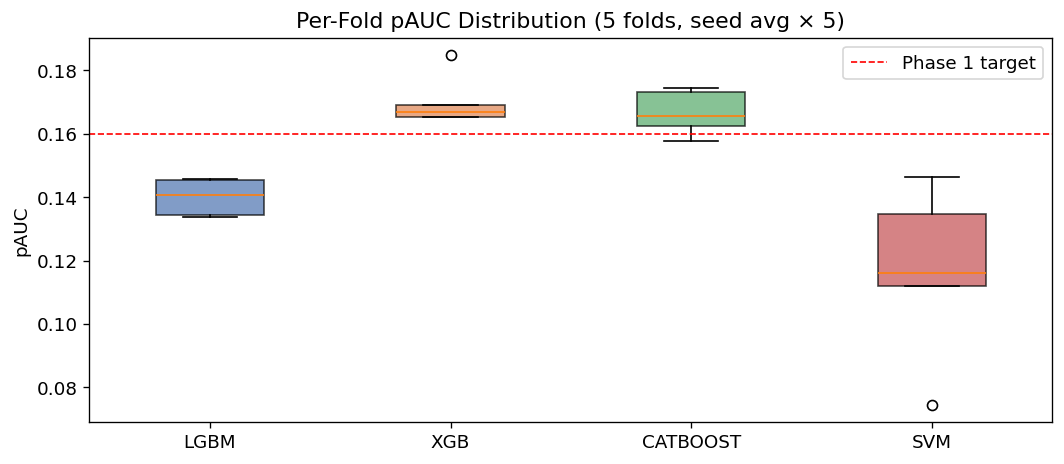

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

fold_data = [
    [fm["pauc"] for fm in cv[m]["fold_metrics"]]
    for m in model_names
]

bp = ax.boxplot(fold_data, labels=[n.upper() for n in model_names],
                patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], colors[:len(model_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.16, color="red", linestyle="--", linewidth=1, label="Phase 1 target")
ax.set_ylabel("pAUC")
ax.set_title("Per-Fold pAUC Distribution (5 folds, seed avg × 5)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. ROC Curves (full OOF)

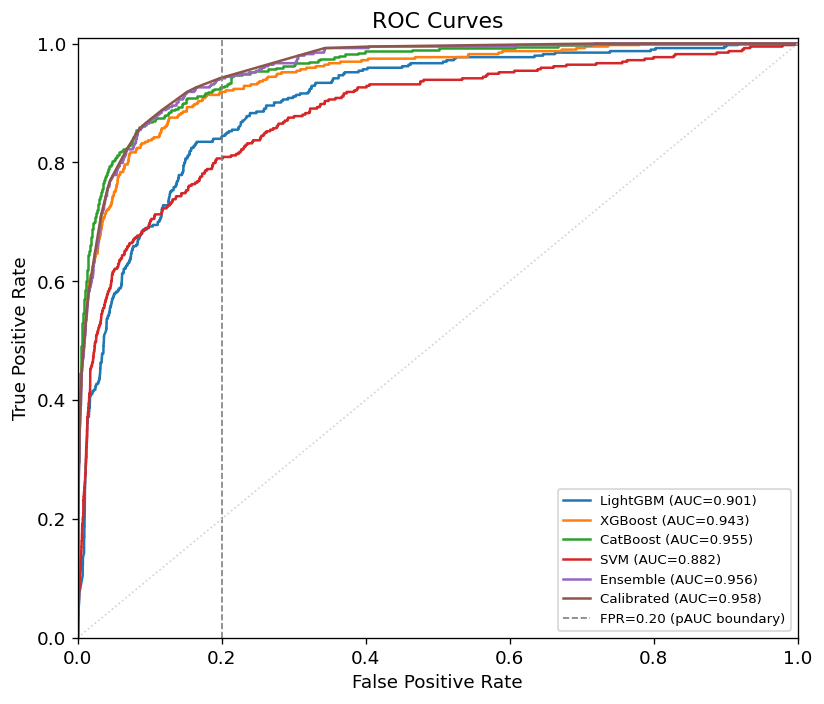

In [11]:
import sys
sys.path.insert(0, "../src")

from isic2024.evaluation.plots import plot_roc_curves

y_true = oof_df["target"].values
oof_dict = {
    "LightGBM":  oof_df["lgbm"].values,
    "XGBoost":   oof_df["xgb"].values,
    "CatBoost":  oof_df["catboost"].values,
    "SVM":       oof_df["svm"].values,
    "Ensemble":  oof_df["ensemble"].values,
    "Calibrated": oof_df["ensemble_calibrated"].values,
}

fig = plot_roc_curves(y_true, oof_dict)
plt.tight_layout()
plt.show()

## 5. Score Distributions (Benign vs Malignant)

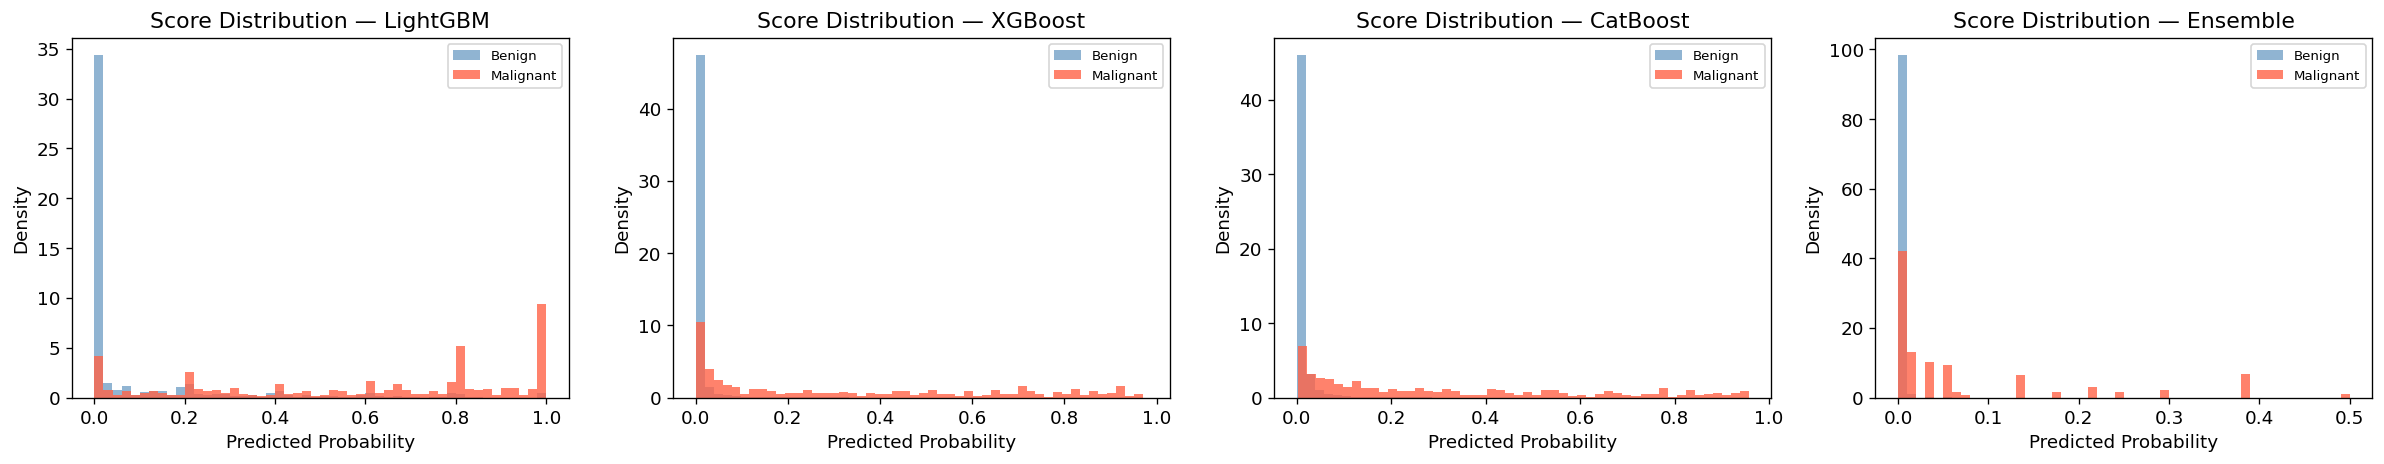

In [12]:
from isic2024.evaluation.plots import plot_score_distributions

# Show GBDT models + ensemble only (SVM has different scale)
gbdt_dict = {
    "LightGBM": oof_df["lgbm"].values,
    "XGBoost":  oof_df["xgb"].values,
    "CatBoost": oof_df["catboost"].values,
    "Ensemble": oof_df["ensemble_calibrated"].values,
}

fig = plot_score_distributions(y_true, gbdt_dict)
plt.tight_layout()
plt.show()

## 6. Feature Importance — XGBoost (Top 30)

2026-03-22 11:54:27.914 | INFO     | isic2024.data.loader:load_data:26 - Loading data from ../data/raw/isic-2024-challenge/train-metadata.csv


Feature count: 88


2026-03-22 11:54:32.436 | INFO     | isic2024.data.loader:load_data:29 - Shape: 401,059 rows × 55 columns
2026-03-22 11:54:33.185 | INFO     | isic2024.data.loader:load_data:30 - Memory usage: 497.4 MB
2026-03-22 11:54:33.199 | INFO     | isic2024.data.loader:load_data:34 - Target distribution (discovered):
target
0    400666
1       393
2026-03-22 11:54:33.202 | INFO     | isic2024.data.loader:load_data:37 - Positive rate: 393/401059 = 0.0980%  (imbalance ratio ≈ 1020:1)
2026-03-22 11:54:33.597 | DEBUG    | isic2024.data.preprocess:_pre_indicators:122 - has_lesion_id: 1131 non-null (5.66% of rows)
2026-03-22 11:54:33.597 | DEBUG    | isic2024.data.preprocess:_drop_columns:148 - Dropping 12 columns: ['mel_thick_mm', 'mel_mitotic_index', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'image_type', 'copyright_license', 'isic_id', 'lesion_id']
2026-03-22 11:54:33.609 | DEBUG    | isic2024.data.preprocess:_fit_impute:166 - Imputing 'age_approx' (153 missing, median=np.float

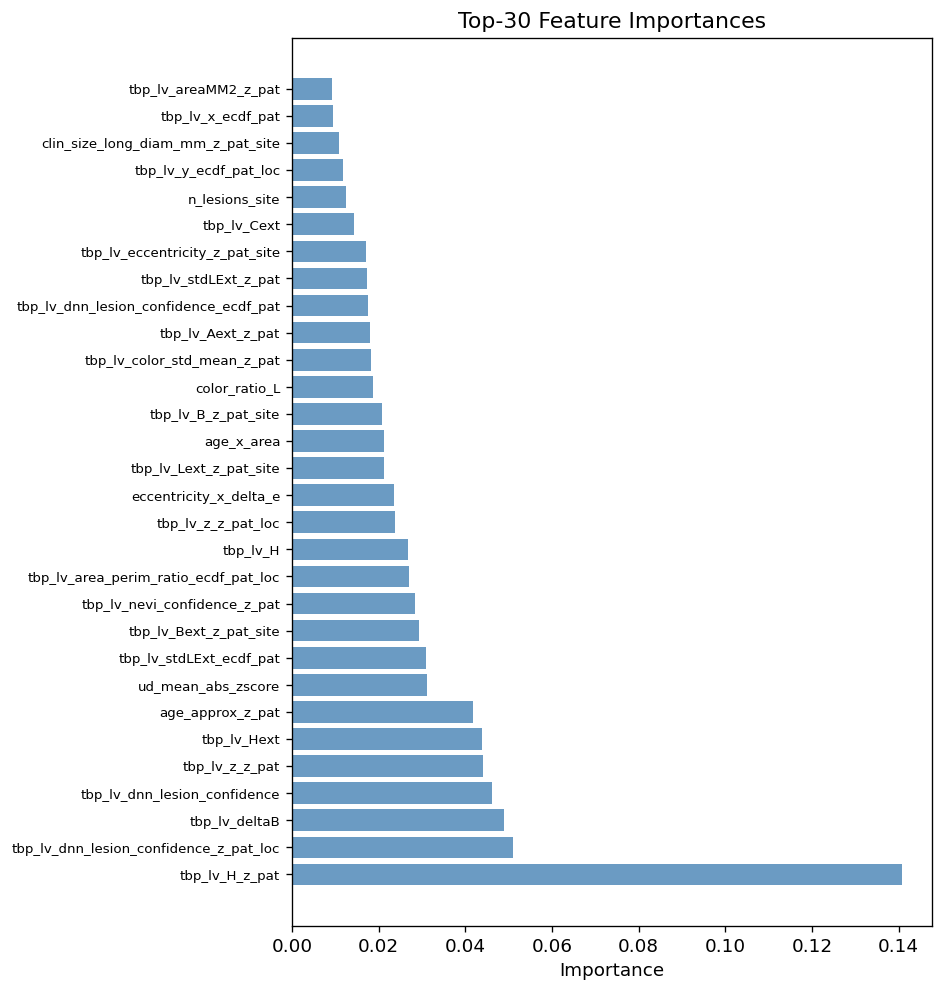


Top 10 features by XGB importance:
   1. tbp_lv_H_z_pat
   2. tbp_lv_dnn_lesion_confidence_z_pat_loc
   3. tbp_lv_deltaB
   4. tbp_lv_dnn_lesion_confidence
   5. tbp_lv_z_z_pat
   6. tbp_lv_Hext
   7. age_approx_z_pat
   8. ud_mean_abs_zscore
   9. tbp_lv_stdLExt_ecdf_pat
  10. tbp_lv_Bext_z_pat_site

  tbp_lv_nevi_confidence: rank #48 of 88

  tbp_lv_dnn_lesion_confidence: rank #4 of 88


In [13]:
import json

from isic2024.evaluation.plots import plot_feature_importance
from isic2024.config import Config
from isic2024.data.loader import load_data
from isic2024.features.pipeline import build_feature_pipeline

with open(OUTPUTS / "feature_names.json") as f:
    feature_names = json.load(f)

print(f"Feature count: {len(feature_names)}")

# Train a quick XGB on a 10K subsample to get importances (for illustration)
# For production importance, load saved model from outputs/
import numpy as np
import pickle

DATA_PATH = Path("../data/raw/isic-2024-challenge/train-metadata.csv")

if DATA_PATH.exists():
    config = Config.from_yaml("../configs/base.yaml")
    df_raw = load_data(DATA_PATH)
    
    # Use a small subsample for speed (importance ranking stable on 20K)
    rng = np.random.default_rng(42)
    idx = rng.choice(len(df_raw), size=min(20000, len(df_raw)), replace=False)
    df_sub = df_raw.iloc[idx].copy()
    
    df_feat, _, _, _ = build_feature_pipeline(df_sub, config, is_train=True)
    
    X = df_feat[feature_names].values.astype(np.float32)
    y = df_feat["target"].values
    
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                        scale_pos_weight=100, verbosity=0, random_state=42)
    xgb.fit(X, y)
    importances = xgb.feature_importances_
    
    fig = plot_feature_importance(feature_names, importances, top_n=30)
    plt.tight_layout()
    plt.show()
    
    # Check where AI scores rank
    idx_sorted = np.argsort(importances)[::-1]
    top_names = [feature_names[i] for i in idx_sorted[:10]]
    print("\nTop 10 features by XGB importance:")
    for rank, name in enumerate(top_names, 1):
        print(f"  {rank:2d}. {name}")
        
    for ai_col in ["tbp_lv_nevi_confidence", "tbp_lv_dnn_lesion_confidence"]:
        if ai_col in feature_names:
            rank = int(np.where(idx_sorted == feature_names.index(ai_col))[0][0]) + 1
            print(f"\n  {ai_col}: rank #{rank} of {len(feature_names)}")
else:
    print(f"Data not found at {DATA_PATH} — skipping importance computation.")
    print(f"Feature names loaded: {feature_names[:5]} ...")

## 7. Summary Metrics Table

In [14]:
from isic2024.evaluation.metrics import compute_metrics

rows = []
for col in ["lgbm", "xgb", "catboost", "svm", "ensemble", "ensemble_calibrated"]:
    m = compute_metrics(y_true, oof_df[col].values)
    rows.append({
        "Model": col,
        "pAUC": f"{m['pauc']:.4f}",
        "AUC": f"{m['roc_auc']:.4f}",
        "Brier": f"{m['brier']:.4f}",
        "ECE": f"{m['ece']:.4f}",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

              Model   pAUC    AUC  Brier    ECE
               lgbm 0.1331 0.9012 0.0507 0.0974
                xgb 0.1532 0.9433 0.0025 0.0087
           catboost 0.1620 0.9555 0.0019 0.0118
                svm 0.1121 0.8821 0.0010 0.0001
           ensemble 0.1653 0.9560 0.2987 0.4990
ensemble_calibrated 0.1672 0.9582 0.0009 0.0000


## 8. Decision Log

### Why XGBoost is the best single model
- `max_delta_step=1` constrains gradient updates under extreme class imbalance (393 positives / ~401K total ≈ 1020:1 ratio). This prevents the model from making overly aggressive step sizes on the rare positive class, leading to more stable convergence.
- `scale_pos_weight=100` combined with `min_child_weight=10` (weight-based): with scale_pos_weight, each positive contributes 100 hessian weight, satisfying the leaf constraint with just 1 positive → fine-grained splitting on positive class enabled.

### LightGBM min_sum_hessian_in_leaf fix
- Early run: LGBM used `min_child_samples=80` (count-based), giving pAUC=0.1217 with Brier score ~0.02 (10× worse than XGB at ~0.001). Root cause: `min_child_samples` ignores `scale_pos_weight` — only ~314 positives per fold, so the count-based constraint throttled positive-class splits severely.
- Fix: `min_child_samples=1` (disabled) + `min_sum_hessian_in_leaf=10.0` mapped as `min_child_weight` in sklearn API. Weight-based constraint works identically to XGB. Result: pAUC 0.1217 → 0.1400, std halved.

### Ensemble design choices
- **Rank averaging** over plain probability averaging: different GBDT libraries output different probability scales (LightGBM with `scale_pos_weight` tends to output higher raw probabilities). Rank normalization makes them comparable.
- **SVM excluded from ensemble**: pAUC=0.1167 with std=0.0245 (high variance from 20K subsample). Including it dragged the blend from 0.1653 to ~0.1608. SVM still trained for course requirements (classical probabilistic model) and reported in OOF.
- **`has_lesion_id` excluded from features**: ALL 393 malignant training cases have a non-null `lesion_id`; test set has no `lesion_id` column at all. Including this feature gave pAUC=0.197 during development but would predict near-zero for ALL test rows.

### Phase 1 target achieved
- Target: pAUC ≥ 0.16
- Calibrated ensemble: **pAUC = 0.1672** ✅